Для інсталювання необхідного пакету в середовищі Anaconda потрібно ввести в терміналі Anaconda:

```python
pip install pulp
pip install networkx
```

Для інсталювання необхідного пакету в середовищі Google Colab потрібно ввести першій комірці:

```python
!pip install pulp
!pip install networkx
```

Більше деталей за [посиланням](https://colab.research.google.com/notebooks/snippets/importing_libraries.ipynb).

## Блок 0. Підключення необхідних пакетів

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Підвищимо розмір графіків за замовчуванням
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 15, 10

## Блок 1. Оголошення та ініціалізація матриці коригування

In [2]:
# Матриця коригування графа
# Тут нуль означає відсутність ребра між вершинами

matrixA = np.asarray([[0, 7, 9, 0, 0, 14],
                     [7, 0, 10, 17, 0, 0],
                     [9, 10, 0, 11, 0, 2],
                     [0, 17, 11, 0, 6, 0],
                     [0, 0, 0, 6, 0, 9],
                     [14, 0, 2, 0, 9, 0]])


## Блок 2. Відображення повністю орієнтованого графа

Побудований орієнтований граф:


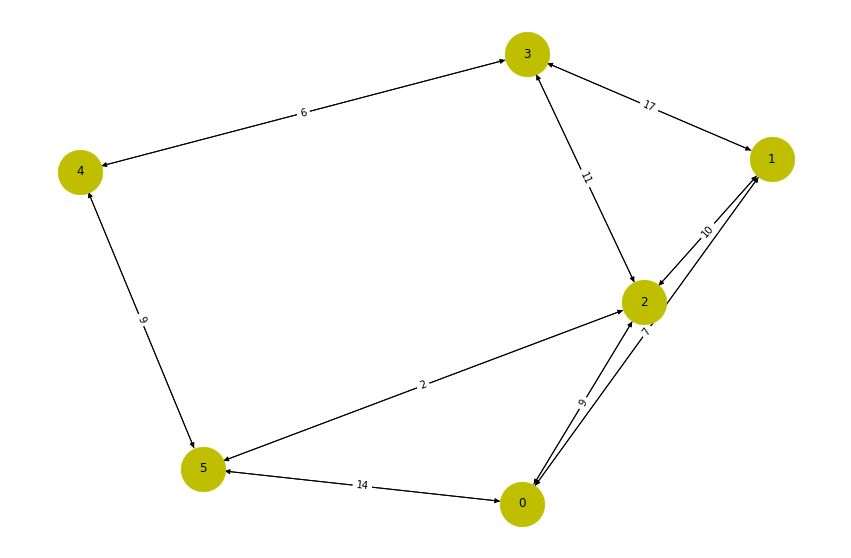

In [8]:
G = nx.DiGraph()

N = matrixA.shape[0]
for i in range(N):
  G.add_node(i)
  
for i in range(N):
  for j in range(N):
    if matrixA[i,j] > 0:
      G.add_edges_from([(i, j)], weight=matrixA[i, j])

print("Побудований орієнтований граф:")


pos = nx.spring_layout(G) 
edge_labels = dict([((u,v), d['weight'])
                 for u, v, d in G.edges(data=True)])

nx.draw_networkx(G, pos, node_size=2000, node_color='y')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis('off')
plt.show()

## Блок 3. Реалізація Алгоритму Дейкстри

In [4]:
# Ініціалізація вхідних параметрів для пошуку найкоротшого шляху

distance = np.zeros(N) 
visited = np.ones(N)

# Ініціалізація цільових вершин n та m через інтерфейс 
#origin = int(input("Початкова вершина: "))
#goal = int(input("Кінцева вершина: "))

# Ініціалізація цільових вершин n та m через код
origin = 0
goal = 4

In [5]:
# Алгоритм Дейкстри
visited[origin] = 0

pred = np.zeros(N)
pred[origin] = origin

for j in range(N):
  if matrixA[origin,j] == 0 and origin != j: 
    distance[j] = 10e10
    pred[j] = -1
  else:
    distance[j] = matrixA[origin,j]
    pred[j] = origin

while np.sum(visited) > 0:
  temp = np.copy(distance) 
  temp[visited == 0] = 10e10
  vmin = np.argmin(temp)
  visited[vmin] = 0
  for j in range(N):
    if matrixA[vmin,j] > 0 and distance[j] > distance[vmin] + matrixA[vmin, j]: 
      distance[j] = distance[vmin] + matrixA[vmin, j]
      pred[j] = vmin

# Найкоротший шлях від початкової вершини до всіх інших
pred = pred.astype(int)

## Блок 4. Відображення найкоротшого шляху на графі 

Найкоротший шлях від вершини 0 до вершини 4:
4 <-- 5 <-- 2 <-- 0

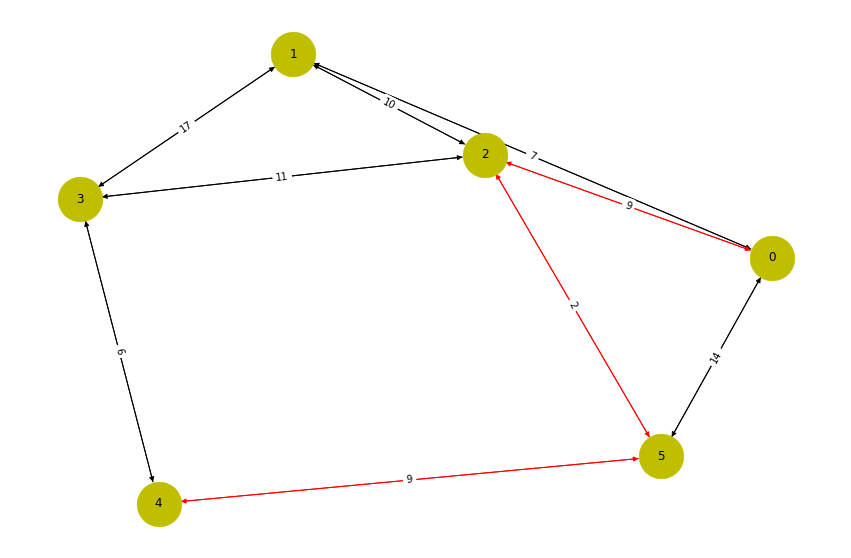

In [9]:
previous = pred[goal]
path = [(previous, goal),(goal, previous)]
print("Найкоротший шлях від вершини " + str(origin) + " до вершини " + str(goal) + 
      ":\n" + str(goal) + " <-- " + str(previous), end="")

while previous != origin:
  path.append((previous, pred[previous]))
  path.append((pred[previous], previous))
  previous = pred[previous]
  print(" <-- "+str(previous), end="")

edge_colors = ['black' if not edge in path else 'red' for edge in G.edges()]

pos=nx.spring_layout(G)
edge_labels=dict([((u, v,),d['weight'])
                 for u, v, d in G.edges(data=True)])

nx.draw_networkx(G, pos, node_size=2000, node_color='y', edge_color=edge_colors)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()